In [15]:
import numpy as np
import matplotlib.pyplot as plt
def f(x):
    return (np.abs(np.sin(x)) + 0.5 * np.cos(2*x) + 0.25 * np.sin(3*x))*10

x_values = np.linspace(1,10,100)
y_values = f(x_values)

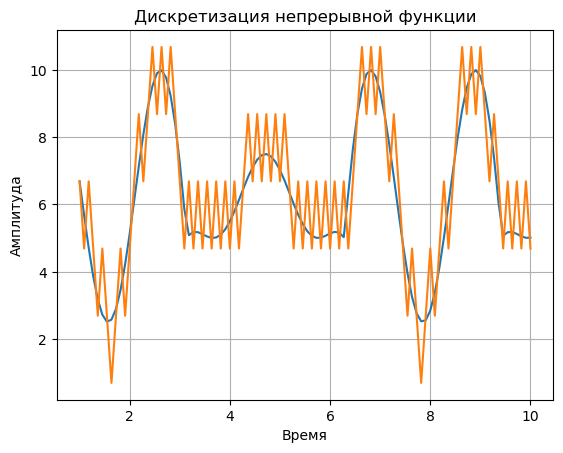

In [16]:
y_disret = [y_values[0]]
for i in range(1,len(y_values)):
    y_disret.append(y_disret[-1]+int(np.sign(y_values[i]-y_disret[-1]))*2)

plt.plot(x_values, y_values)
plt.plot(x_values, y_disret)
plt.title('Дискретизация непрерывной функции')
plt.xlabel('Время')
plt.ylabel('Амплитуда')
plt.grid()


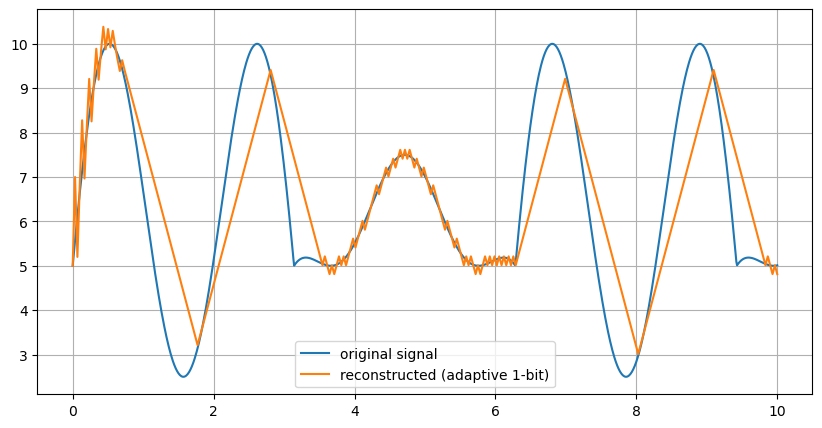

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return (np.abs(np.sin(x)) +
            0.5*np.cos(2*x) +
            0.25*np.sin(3*x)) * 10

x_ = np.linspace(0, 10, 1000)
x = np.linspace(0, 10, 300)

y_ = f(x_)
y = f(x)

theta = 1.0
alpha = 0.5
M_min = 0.2
N = len(y)

y_hat = np.zeros(N)
c = np.zeros(N)
p = np.zeros(N)
M = np.zeros(N)

y_hat[0] = y[0]
M[0] = 2.0
p[0] = 0.0

for i in range(1, N):
    c[i] = np.sign(y[i] - y_hat[i - 1])
    y_hat[i] = y_hat[i - 1] + M[i - 1] * c[i]

    p[i] = alpha * p[i - 1] + (1 - alpha) * abs(y[i] - y[i - 1])

    if i < N - 1:
        if p[i] > theta:
            M[i] = max(1.1 * M[i - 1], M_min)
        else:
            M[i] = max(0.9 * M[i - 1], M_min)

plt.figure(figsize=(10, 5))
plt.plot(x_, y_, label="original signal")
plt.plot(x, y_hat, label="reconstructed (adaptive 1-bit)")
plt.legend()
plt.grid()
plt.show()